<a href="https://colab.research.google.com/github/weichen642/26fall-datman/blob/main/PS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital public-service demand and responsiveness

## PS0

How do public-service demand and reported responsiveness vary over time in Guangzhou 12345 and Hong Kong 1823? As an exploratory extension, how does Hong Kong hotline demand vary alongside rainfall?

This project examines smart-city governance, public value, and community resilience in the Pearl River Delta. This assignment develops the data-management component of describetives service demand and administrative indicators.

In [1]:
# Data processing
import pandas as pd
import json
import re

In [2]:
# File and web access
from pathlib import Path
from io import StringIO
from urllib.request import Request, urlopen
from urllib.error import URLError

In [3]:
# Utility tools
import hashlib

from html import unescape
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
from IPython.display import display

In [4]:
# Project settings

USE_CACHE = False

START, END = '2023-07', '2026-02'

In [5]:
# Create folder for raw data

RAW = Path('raw')

RAW.mkdir(exist_ok=True)

In [6]:
# Store download records

ledger = []

In [7]:
def download(url, filename):
    # Set the local file path
    path = RAW / filename

    # Read from local cache if enabled
    if USE_CACHE:
        content = path.read_bytes()
        mode = 'explicit cache replay'

    # Otherwise, download from the Internet
    else:
        request = Request(url, headers={'User-Agent': 'Mozilla/5.0 academic coursework'})

        # Retry up to 3 times if the download fails
        for attempt in range(3):
            try:
                with urlopen(request, timeout=30) as response:
                    content = response.read()
                break
            except (URLError, TimeoutError) as exc:
                if attempt == 2:
                    raise RuntimeError('Download failed after 3 attempts: ' + url) from exc
                print('Retrying:', filename, 'attempt', attempt + 2)

        # Save the downloaded file locally
        path.write_bytes(content)
        mode = 'Internet'

    # Record download information for reproducibility
    ledger.append({'url': url, 'file': filename, 'mode': mode, 'run_time_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(content).hexdigest()})

    # Return the file content as text
    return content.decode('utf-8-sig')

In [8]:
GZ_URLS = ['https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=5703baa6-367f-11ee-83cf-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=fc86f701-5067-11ee-83cf-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=1aaa8f2d-9991-11ee-83cf-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=5bb8d49d-fb92-11ee-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=f1e5a50e-173e-11ef-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=e662460c-5ac7-11ef-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=e69f6e38-6fdc-11ef-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=db89d4bb-8f8e-11ef-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=b6af19cf-a65b-11ef-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=52119323-bc45-11ef-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=1b84de85-d256-11ef-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=56583d60-4b26-11f0-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=74b87dfe-4b26-11f0-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=95f72143-4b26-11f0-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=4e6ebc42-5ade-11f0-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=f6379bd4-726c-11f0-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=03e3c66f-8c5b-11f0-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=3c97eb73-a961-11f0-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=f33e21b1-c5ef-11f0-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=e5e63c4b-d410-11f0-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=fd4ee1b8-ec5d-11f0-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=091e277b-1447-11f1-b12e-38adbed808fb', 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=9dd83a01-229b-11f1-b12e-38adbed808fb']

# Download all Guangzhou monthly reports in parallel
def read_gz_raw(url):
    page_id = url.split('id=')[1]
    html = download(url, 'gz_' + page_id + '.html')
    return {'url': url, 'page_id': page_id, 'html': html}

with ThreadPoolExecutor(max_workers=4) as pool:
    gz_raw = list(pool.map(read_gz_raw, GZ_URLS))

print('Downloaded reports:', len(gz_raw))

print(gz_raw[0]['html'][:3000])

Downloaded reports: 23
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">
<html xmlns="http://www.w3.org/1999/xhtml">
<head>
    <meta http-equiv="Content-Type" content="text/html; charset=utf-8"/>
    <link href="http://www.gz.gov.cn/xhtml/images/favicon.ico" rel="shortcut icon" type="image/x-icon"/>
    <title>广州12345政务服务便民热线</title>
    <meta name="SiteName" content="广州市人民政府门户网站">
<meta name="SiteDomain" content="www.gz.gov.cn">
<meta name="SiteIDCode" content="4401000004">
<meta name="ColumnName" content="广州12345政务服务便民热线栏目">
<meta name="ColumnType" content="咨询投诉">
<meta name="ColumnDescription" content=广州12345政务服务便民热线是广州市人民政府设立，整合全市各类非紧急类政府服务专线，以便民、智能、高效为服务理念，为公众提供政务咨询、民生诉求、政民互动、投诉举报、效能监察等公共服务，提高城市治理法治化、精准化、智能化、专业化水平。">
<meta name="ColumnKeywords" content="广州12345政务服务便民热线">
 <meta name="PubDate" content="2019-01-01 00:00:00">
	<meta name="Author" content="">
	<meta name="ContentSource" content="广州12345政务服务便民热线">

In [9]:
def clean_html(html: str) -> str:
    # Convert webpage HTML into plain text
    html = re.sub(r"<script[\s\S]*?</script>", " ", html, flags=re.I)
    html = re.sub(r"<style[\s\S]*?</style>", " ", html, flags=re.I)
    text = re.sub(r"<[^>]+>", "\n", html)
    text = unescape(text)
    text = re.sub(r"[ \t\r\f\v]+", " ", text)
    text = re.sub(r"\n\s*", "\n", text)
    return text.strip()

In [10]:
# Clean all Guangzhou reports
for item in gz_raw:
    item['text'] = clean_html(item['html'])

print(gz_raw[0]['text'][:3000])

广州12345政务服务便民热线
无障碍
长者助手
微信
小程序
广州12345政务服务便民热线
我要诉求
自助下单
在线客服
领导接电
我要查询
知识库
案例公开
数据播报
关于热线
登录
您现在的位置：
广州12345政务服务便民热线
>
数据播报
>
数据播报详情
2023年7月，广州12345政务服务便民热线市民来电办理情况
2023-08-09 14:38:24
来源：广州12345政务服务便民热线
分享至：
微信扫一扫：分享
扫一扫，分享给好友或朋友圈
打印
2023年7月，热线共接到市民来电1247677次。应办转派工单382319件（含电话，微信，网页等），按时办结率99.84%，咨询类工单平均处理时长0天18时，非咨询类工单平均办理时长5天1时，市民满意率72.78%。
11个区承办工单量从多到少分别是：白云区（30827），天河区（26489），番禺区（20494），海珠区（15520），黄埔区（12482），增城区（12217），花都区（11671），越秀区（11261），荔湾区（11112），南沙区（9158），从化区（2660）。
承办工单量前十的市属部门分别是：市公安局（28313），市医保局（9268），市公积金中心（5045），市交通局（4576），市邮政管理局（2976），市税务局（2936），市人社局（1610），市市场监管局（1584），市卫健委（1561），市供电局（1382）。
工单量前十的问题类型分别是：人社类（39339），城管类（35205），消费维权（31954），公安事项（29072），住建类（19596），交通类（10654），环保类（10338），公共类（8722），教育类（7781），市场监管类（6336）。


In [11]:
def parse_duration_days(value):
    # Convert both "X天X时" and "X.XX天" into days
    m = re.match(r'(\d+(?:\.\d+)?)天(?:(\d+(?:\.\d+)?)时)?', value)
    if m:
        return float(m.group(1)) + float(m.group(2) or 0) / 24
    return None

In [12]:
def parse_pairs(segment):
    # Convert "name(count)" text into structured name-count pairs
    pairs = re.findall(r'([^，、（）\(\)]+)[（(](\d+)[）)]', segment)
    return [{'name': name.strip(), 'count': int(count)} for name, count in pairs]

In [13]:
def parse_page(text, url, page_id):
    # Extract basic report information
    title = re.search(r'(\d{4})年(\d{1,2})月，广州12345政务服务便民热线市民来电办理情况', text)
    publish = re.search(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})', text)

    main = {
        'id': page_id,
        'url': url,
        'year': int(title.group(1)) if title else None,
        'month': int(title.group(2)) if title else None,
        'period': f'{title.group(1)}-{int(title.group(2)):02d}' if title else None,
        'published_at': publish.group(1) if publish else None
    }

    # Extract main service indicators
    m = re.search(r'热线共接到市民来电(\d+)(?:次|通)', text)
    main['calls'] = int(m.group(1)) if m else None

    m = re.search(r'应办转派工单(\d+)件', text)
    main['transferred_work_orders'] = int(m.group(1)) if m else None

    m = re.search(r'按时办结率(\d+(?:\.\d+)?)%', text)
    main['on_time_completion_rate_pct'] = float(m.group(1)) if m else None

    m = re.search(r'咨询类工单平均处理时长([0-9.]+天(?:[0-9.]+时)?)', text)
    main['consultation_avg_days'] = parse_duration_days(m.group(1)) if m else None

    m = re.search(r'非咨询类工单平均办理时长([0-9.]+天(?:[0-9.]+时)?)', text)
    main['non_consultation_avg_days'] = parse_duration_days(m.group(1)) if m else None

    m = re.search(r'市民满意率(\d+(?:\.\d+)?)%', text)
    main['citizen_satisfaction_pct'] = float(m.group(1)) if m else None

    # Extract district, department, and issue-type rankings
    m = re.search(r'11个区承办工单量从多到少分别是：(.+?)(?:\n|承办工单量前十)', text, flags=re.S)
    districts = parse_pairs(m.group(1)) if m else []

    m = re.search(r'承办工单量前十的市属部门分别是：(.+?)(?:\n|工单量前十)', text, flags=re.S)
    departments = parse_pairs(m.group(1)) if m else []

    m = re.search(r'工单量前十的问题类型分别是：(.+?)(?:\n|$)', text, flags=re.S)
    issue_types = parse_pairs(m.group(1)) if m else []

    return main, districts, departments, issue_types


main, districts, departments, issue_types = parse_page(text=gz_raw[0]['text'], url=gz_raw[0]['url'], page_id=gz_raw[0]['page_id'])

print(main)
print(districts[:3])
print(departments[:3])
print(issue_types[:3])

{'id': '5703baa6-367f-11ee-83cf-38adbed808fb', 'url': 'https://www.gz.gov.cn/gz12345/dataDeclare/dataDeclareDetail.do?id=5703baa6-367f-11ee-83cf-38adbed808fb', 'year': 2023, 'month': 7, 'period': '2023-07', 'published_at': '2023-08-09 14:38:24', 'calls': 1247677, 'transferred_work_orders': 382319, 'on_time_completion_rate_pct': 99.84, 'consultation_avg_days': 0.75, 'non_consultation_avg_days': 5.041666666666667, 'citizen_satisfaction_pct': 72.78}
[{'name': '白云区', 'count': 30827}, {'name': '天河区', 'count': 26489}, {'name': '番禺区', 'count': 20494}]
[{'name': '市公安局', 'count': 28313}, {'name': '市医保局', 'count': 9268}, {'name': '市公积金中心', 'count': 5045}]
[{'name': '人社类', 'count': 39339}, {'name': '城管类', 'count': 35205}, {'name': '消费维权', 'count': 31954}]


In [14]:
# Parse all Guangzhou monthly reports
gz_rows = []

for item in gz_raw:
    row, districts, departments, issues = parse_page(item['text'], item['url'], item['page_id'])
    gz_rows.append(row)

gz = pd.DataFrame(gz_rows)

# Check the parsed data
print('Parsed reports:', len(gz))
display(gz.head())

Parsed reports: 23


,id,url,year,month,period,published_at,calls,transferred_work_orders,on_time_completion_rate_pct,consultation_avg_days,non_consultation_avg_days,citizen_satisfaction_pct
0,5703baa6-367f-11ee-83cf-38adbed808fb,https://www.gz.gov.cn/gz12345/dataDeclare/data...,2023,7,2023-07,2023-08-09 14:38:24,1247677,382319,99.84,0.750000,5.041667,72.78
1,fc86f701-5067-11ee-83cf-38adbed808fb,https://www.gz.gov.cn/gz12345/dataDeclare/data...,2023,8,2023-08,2023-09-11 13:56:44,1225275,387648,99.79,0.791667,4.916667,72.07
2,1aaa8f2d-9991-11ee-83cf-38adbed808fb,https://www.gz.gov.cn/gz12345/dataDeclare/data...,2023,11,2023-11,2023-12-13 16:24:59,1205816,400961,99.85,0.750000,4.708333,70.39
3,5bb8d49d-fb92-11ee-b12e-38adbed808fb,https://www.gz.gov.cn/gz12345/dataDeclare/data...,2024,3,2024-03,2024-04-16 09:40:51,1266073,417042,99.89,0.670000,4.400000,75.27
4,f1e5a50e-173e-11ef-b12e-38adbed808fb,https://www.gz.gov.cn/gz12345/dataDeclare/data...,2024,4,2024-04,2024-05-21 14:54:18,1245652,414519,99.87,0.720000,4.740000,72.36


In [15]:
# Format and sort the monthly data
gz['period'] = pd.PeriodIndex(gz['period'], freq='M')
gz = gz.sort_values('period').reset_index(drop=True)

# Check the time range
print('First month:', gz['period'].min())
print('Last month:', gz['period'].max())
display(gz[['period', 'calls']].head())

First month: 2023-07
Last month: 2026-02


,period,calls
0,2023-07,1247677
1,2023-08,1225275
2,2023-11,1205816
3,2024-03,1266073
4,2024-04,1245652


In [16]:
# Check Guangzhou data completeness
assert not gz['period'].duplicated().any()
assert gz['period'].between(pd.Period(START), pd.Period(END)).all()

expected = pd.period_range(START, END, freq='M')
missing_months = expected.difference(gz['period'])

print('Observed months:', len(gz), 'of', len(expected))
print('Missing months:', list(missing_months))

Observed months: 23 of 32
Missing months: [Period('2023-09', 'M'), Period('2023-10', 'M'), Period('2023-12', 'M'), Period('2024-01', 'M'), Period('2024-02', 'M'), Period('2024-05', 'M'), Period('2024-06', 'M'), Period('2025-02', 'M'), Period('2025-04', 'M')]


In [17]:
display(gz[['period', 'calls', 'transferred_work_orders',
            'non_consultation_avg_days', 'citizen_satisfaction_pct']].head())

,period,calls,transferred_work_orders,non_consultation_avg_days,citizen_satisfaction_pct
0,2023-07,1247677,382319,5.041667,72.78
1,2023-08,1225275,387648,4.916667,72.07
2,2023-11,1205816,400961,4.708333,70.39
3,2024-03,1266073,417042,4.400000,75.27
4,2024-04,1245652,414519,4.740000,72.36


In [18]:
metrics = ['calls', 'transferred_work_orders', 'on_time_completion_rate_pct',
           'consultation_avg_days', 'non_consultation_avg_days', 'citizen_satisfaction_pct']
display(gz[metrics].describe().T.round(3))
display(gz[metrics].isna().sum().rename('missing'))
print(f"Across the {len(gz)} observed months, mean monthly calls were {gz.calls.mean():,.0f}.")
print(f"Mean monthly non-consultation case duration was {gz.non_consultation_avg_days.mean():.2f} days.")
print(f"The unweighted mean of published monthly satisfaction rates was {gz.citizen_satisfaction_pct.mean():.2f}%.")

,count,mean,std,min,25%,50%,75%,max
calls,23.0,1124633.174,140999.761,674099.00,1056724.000,1136254.00,1220581.500,1323374.00
transferred_work_orders,23.0,414988.087,42243.694,263578.00,414445.000,420969.00,434469.000,481033.00
on_time_completion_rate_pct,23.0,99.834,0.060,99.69,99.790,99.84,99.885,99.95
consultation_avg_days,23.0,0.777,0.274,0.59,0.630,0.72,0.760,1.78
non_consultation_avg_days,23.0,5.294,0.602,4.40,4.918,5.06,5.740,6.88
citizen_satisfaction_pct,23.0,71.197,8.472,64.17,67.230,68.73,71.460,96.85


,missing
calls,0
transferred_work_orders,0
on_time_completion_rate_pct,0
consultation_avg_days,0
non_consultation_avg_days,0
citizen_satisfaction_pct,0


Across the 23 observed months, mean monthly calls were 1,124,633.
Mean monthly non-consultation case duration was 5.29 days.
The unweighted mean of published monthly satisfaction rates was 71.20%.


<Axes: >

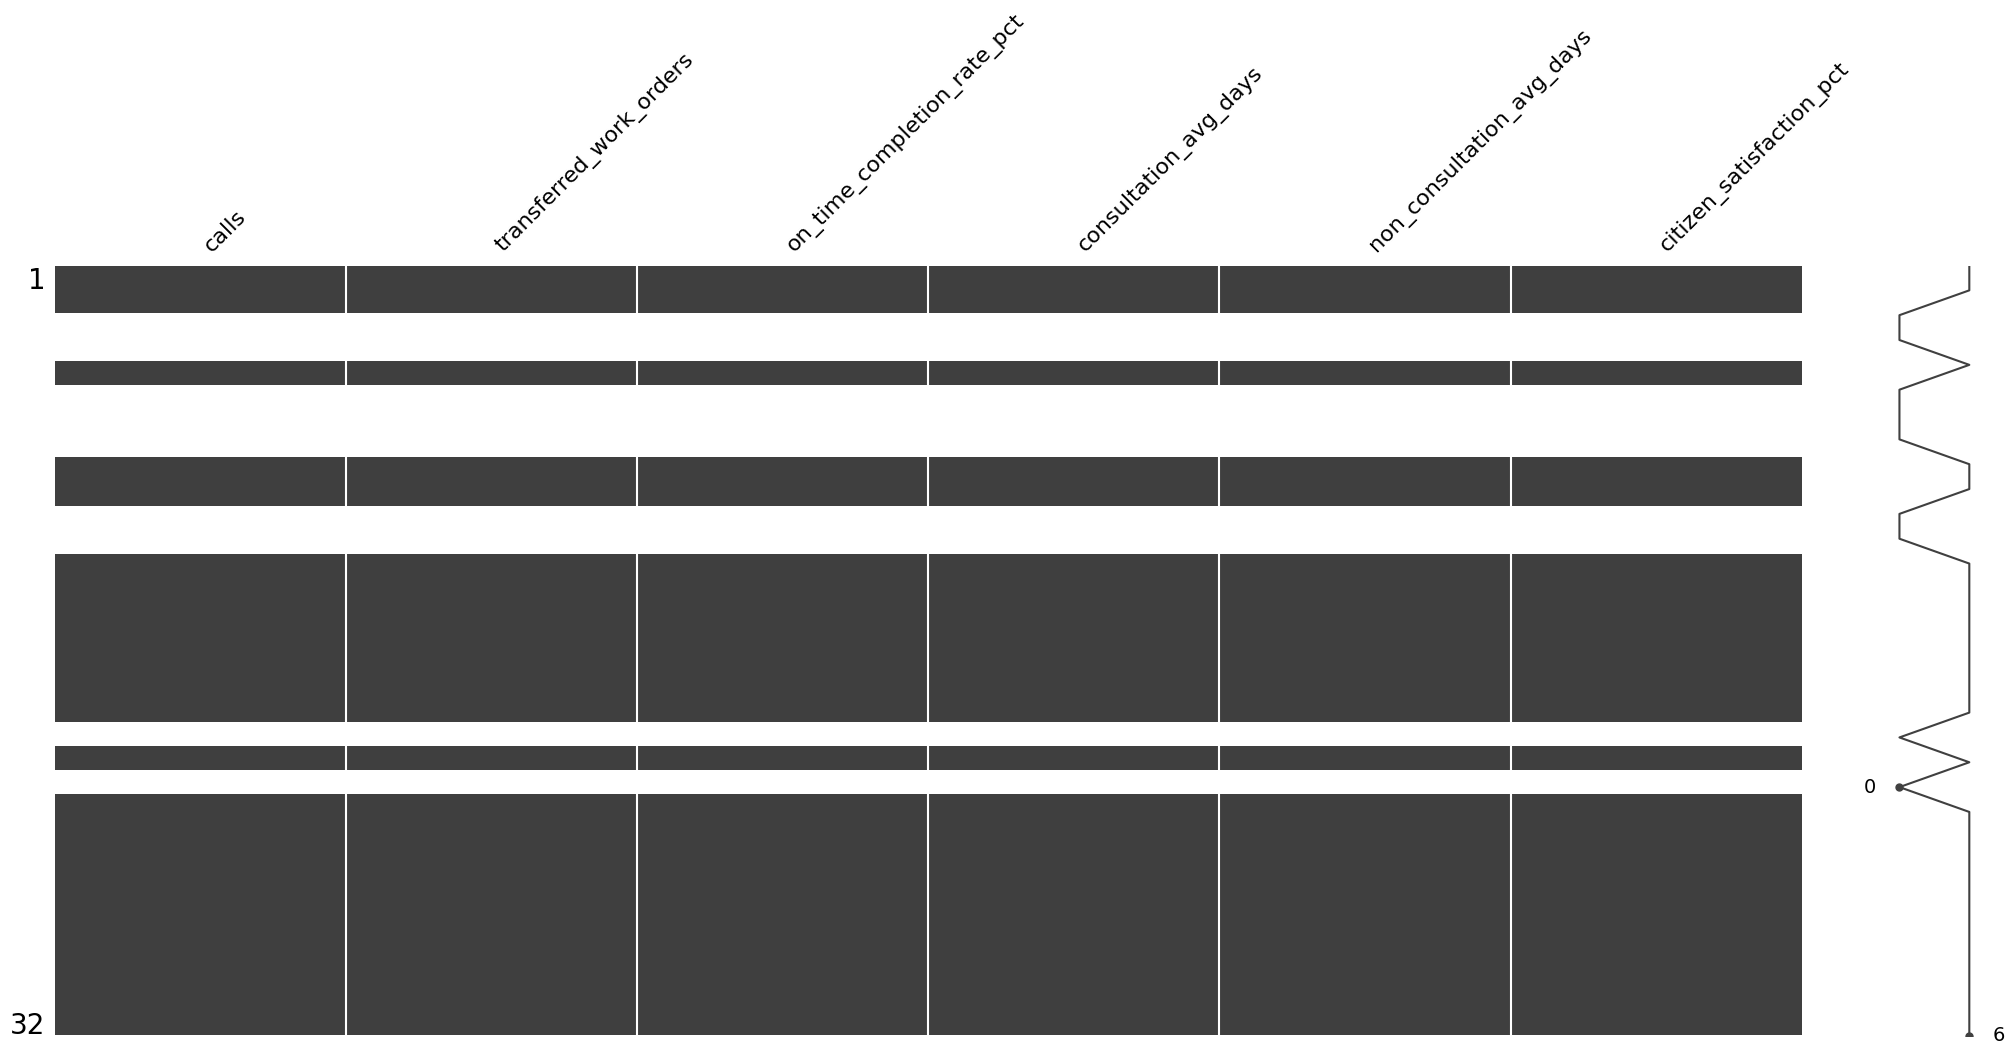

In [19]:
# Visualize missing data
import missingno as msno

cols = ['calls', 'transferred_work_orders', 'on_time_completion_rate_pct',
        'consultation_avg_days', 'non_consultation_avg_days', 'citizen_satisfaction_pct']

gz_missing = gz.set_index('period')[cols].reindex(expected)

msno.matrix(gz_missing)

## PS1

PS1 examines monthly activity and responsiveness in Hong Kong's 1823 public service hotline, focusing on call volume, abandoned calls, call handling time, and the share of abandoned calls.

The analysis then links the hotline data with monthly rainfall measured at the Hong Kong Observatory and compares hotline activity between months with rainfall above and at or below the sample median.

In [20]:
# Download Hong Kong 1823 data
HK_URL = 'https://www.1823.gov.hk/datagovhk/statistics/1823_statistic.json'
hk_raw = json.loads(download(HK_URL, 'hk1823.json'))

# Inspect the raw data
print('Number of records:', len(hk_raw))
print(hk_raw[0])

Number of records: 92
{'Date': {'Year': '2019', 'Month': 'Jan'}, 'No._of_calls_received': '364610', 'No._of_abandoned_calls': '22073', '%_of_calls_answered_within_12seconds': '65%', 'Average_call_handling_time(seconds)': '400', 'No._of_non_voice': {'No._of_emails': '28771', 'No._of_faxes': '686', 'No._of_Apps-inbound': '16042', 'No._of_SMS': '2274', 'No._of_web-inbound': '4459'}, 'Unique_page_view_1823_web': '293109', ' Enquiries': {'Call': '164732', 'Email': '2594', 'Fax': '50', 'Apps': '794', 'Chatbot': '', 'Voicebot': '', 'SMS': '198', 'Web': '466'}, 'ServiceRequestORComplaints': {'Call': '26397', 'Email': '5289', 'Fax': '318', 'Apps': '10952', 'Voicebot': '', 'SMS': '141', 'Web': '2958'}, ' Suggestions': {'Call': '567', 'Email': '79', 'Fax': '3', 'Apps': '71', 'SMS': '0', 'Web': '20'}, ' Compliments': {'Call': '53', 'Email': '22', 'Fax': '0', 'Apps': '35', 'SMS': '0', 'Web': '5'}, '1st_time_resolution': '99%', 'Cases_involving_more_than_1_department': '3%', 'Case_assigned_to_depart

In [22]:
# Convert raw Hong Kong 1823 records into a structured table
month_map = dict(zip(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], range(1,13)))

rows = []
for item in hk_raw:
    rows.append({
        'year': int(item['Date']['Year']),
        'month': month_map[item['Date']['Month'].strip()[:3]],
        'calls': item.get('No._of_calls_received'),
        'abandoned_calls': item.get('No._of_abandoned_calls'),
        'call_handling_seconds': item.get('Average_call_handling_time(seconds)')
    })

hk = pd.DataFrame(rows)

# Check the result
display(hk.head())

,year,month,calls,abandoned_calls,call_handling_seconds
0,2019,1,364610,22073,400
1,2019,2,283797,14802,389
2,2019,3,466219,25874,411
3,2019,4,738963,40261,455
4,2019,5,463534,55282,451


In [23]:
# Convert service indicators to numeric values
for col in ['calls', 'abandoned_calls', 'call_handling_seconds']:
    hk[col] = pd.to_numeric(hk[col].astype('string').str.replace(',', '', regex=False), errors='raise')

# Check data types
print(hk.dtypes)

year                     int64
month                    int64
calls                    Int64
abandoned_calls          Int64
call_handling_seconds    Int64
dtype: object


In [24]:
# Create monthly period and keep the study period
hk['period'] = pd.to_datetime(hk[['year','month']].assign(day=1)).dt.to_period('M')
hk = hk.loc[hk.period.between(pd.Period(START), pd.Period(END))].sort_values('period').copy()

# Check the time range
print('First month:', hk.period.min())
print('Last month:', hk.period.max())
print('Number of months:', len(hk))

First month: 2023-07
Last month: 2026-02
Number of months: 32


In [25]:
# Validate the Hong Kong hotline data
assert not hk.period.duplicated().any()
assert hk.calls.gt(0).all()
assert hk.abandoned_calls.between(0, hk.calls).all()

# Calculate abandoned-call percentage
hk['abandoned_pct'] = 100 * hk.abandoned_calls / hk.calls

display(hk.head())

,year,month,calls,abandoned_calls,call_handling_seconds,period,abandoned_pct
54,2023,7,251815,17458,427,2023-07,6.932867
55,2023,8,256129,16791,417,2023-08,6.555681
56,2023,9,259439,22310,447,2023-09,8.599324
57,2023,10,296175,24706,439,2023-10,8.34169
58,2023,11,233542,16375,433,2023-11,7.011587


In [26]:
# Summary statistics
display(hk[['calls','abandoned_calls','call_handling_seconds','abandoned_pct']].describe().T.round(3))

print(f"Hong Kong: {len(hk)} months; mean monthly calls {hk.calls.mean():,.0f}.")
print(f"Call-weighted abandonment over this window: {100*hk.abandoned_calls.sum()/hk.calls.sum():.2f}%.")

,count,mean,std,min,25%,50%,75%,max
calls,32.0,214403.0,36919.705,131630.0,189435.5,217223.0,242607.0,296175.0
abandoned_calls,32.0,15142.375,4602.538,6408.0,11533.0,16103.5,18037.0,24706.0
call_handling_seconds,32.0,444.906,17.692,413.0,433.0,446.5,458.5,485.0
abandoned_pct,32.0,6.925,1.216,3.994,6.282,6.972,7.802,9.706


Hong Kong: 32 months; mean monthly calls 214,403.
Call-weighted abandonment over this window: 7.06%.


In [27]:
# Download Hong Kong Observatory rainfall data
RAIN_URL = 'https://data.weather.gov.hk/weatherAPI/cis/csvfile/HKO/ALL/daily_HKO_RF_ALL.csv'
rain_text = download(RAIN_URL, 'hko_rainfall.csv')

# Read the CSV and inspect
rain = pd.read_csv(StringIO(rain_text), skiprows=2, dtype=str)
print('Shape:', rain.shape)
display(rain.head())

Shape: (49496, 5)


,年/Year,月/Month,日/Day,數值/Value,數據完整性/data Completeness
0,1884,3,1,0.0,C
1,1884,3,2,0.0,C
2,1884,3,3,0.0,C
3,1884,3,4,0.0,C
4,1884,3,5,0.0,C


In [28]:
# Clean the rainfall table structure
assert rain.shape[1] == 5
rain.columns = ['year', 'month', 'day', 'rainfall_raw', 'completeness']

# Keep valid year rows and the study period
rain = rain.loc[rain.year.str.fullmatch(r'\d{4}', na=False)].copy()
rain = rain.loc[rain.year.astype(int).between(int(START[:4]), int(END[:4]))].copy()

display(rain.head())

,year,month,day,rainfall_raw,completeness
48153,2023,1,1,0.1,C
48154,2023,1,2,Trace,C
48155,2023,1,3,Trace,C
48156,2023,1,4,Trace,C
48157,2023,1,5,0.0,C


In [29]:
# Create daily dates and monthly periods
rain['date'] = pd.to_datetime(rain[['year', 'month', 'day']].astype(int), errors='raise')
rain['period'] = rain.date.dt.to_period('M')
rain = rain.loc[rain.period.between(pd.Period(START), pd.Period(END))].copy()

# Check dates
assert not rain.date.duplicated().any()
print('First date:', rain.date.min())
print('Last date:', rain.date.max())
print('Daily records:', len(rain))

First date: 2023-07-01 00:00:00
Last date: 2026-02-28 00:00:00
Daily records: 974


In [30]:
# Process trace rainfall and missing observations
rain['trace'] = rain.rainfall_raw.eq('Trace')

# Trace means less than 0.05 mm; use 0 as the lower-bound estimate
rain['rainfall_mm'] = pd.to_numeric(rain.rainfall_raw.replace({'Trace': '0', '***': None}), errors='raise')

# Keep only complete and valid daily observations
rain['valid'] = rain.completeness.eq('C') & rain.rainfall_mm.notna()
rain.loc[~rain.valid, 'rainfall_mm'] = float('nan')

# Check
display(rain[['date', 'rainfall_raw', 'rainfall_mm', 'trace', 'valid']].head(10))

,date,rainfall_raw,rainfall_mm,trace,valid
48334,2023-07-01,4.7,4.7,False,True
48335,2023-07-02,15.6,15.6,False,True
48336,2023-07-03,3.6,3.6,False,True
48337,2023-07-04,10.6,10.6,False,True
48338,2023-07-05,Trace,0.0,True,True
48339,2023-07-06,Trace,0.0,True,True
48340,2023-07-07,0.3,0.3,False,True
48341,2023-07-08,0.0,0.0,False,True
48342,2023-07-09,Trace,0.0,True,True
48343,2023-07-10,0.0,0.0,False,True


Rainfall is measured at the Hong Kong Observatory station. The monthly lower bound treats trace rainfall as zero; the upper bound adds 0.05 mm per trace day. Incomplete months remain unavailable. This station cannot represent every Hong Kong neighborhood, and its rainfall is not assigned to Guangzhou.

In [31]:
# Aggregate daily rainfall into monthly rainfall
rain_month = rain.groupby('period').agg(
    days_present=('date', 'size'),
    valid_days=('valid', 'sum'),
    trace_days=('trace', 'sum'),
    rainfall_lower_mm=('rainfall_mm', lambda x: x.sum(min_count=1))
)

# Check monthly rainfall
display(rain_month.head())

,days_present,valid_days,trace_days,rainfall_lower_mm
period,,,,
2023-07,31,31,5,175.2
2023-08,31,31,5,140.7
2023-09,30,30,3,1067.1
2023-10,31,31,7,546.0
2023-11,30,30,2,3.3


In [32]:
# Check whether each month has complete daily observations
rain_month['expected_days'] = rain_month.index.days_in_month
rain_month['complete_month'] = rain_month.valid_days.eq(rain_month.expected_days)

# Incomplete months are treated as unavailable
rain_month.loc[~rain_month.complete_month, 'rainfall_lower_mm'] = float('nan')

# Calculate an upper bound for trace rainfall
rain_month['rainfall_upper_mm'] = rain_month.rainfall_lower_mm + 0.05 * rain_month.trace_days

display(rain_month.head())

,days_present,valid_days,trace_days,rainfall_lower_mm,expected_days,complete_month,rainfall_upper_mm
period,,,,,,,
2023-07,31,31,5,175.2,31,True,175.45
2023-08,31,31,5,140.7,31,True,140.95
2023-09,30,30,3,1067.1,30,True,1067.25
2023-10,31,31,7,546.0,31,True,546.35
2023-11,30,30,2,3.3,30,True,3.40


In [36]:
# Merge hotline and rainfall data by month
merged = hk.merge(rain_month, left_on='period', right_index=True, how='left')

# Check the merged data
display(merged[['period', 'calls', 'abandoned_calls', 'call_handling_seconds', 'rainfall_lower_mm']].head())

print('Total months:', len(merged))
print('Missing rainfall months:', merged['rainfall_lower_mm'].isna().sum())

assert merged['period'].is_unique

,period,calls,abandoned_calls,call_handling_seconds,rainfall_lower_mm
54,2023-07,251815,17458,427,175.2
55,2023-08,256129,16791,417,140.7
56,2023-09,259439,22310,447,1067.1
57,2023-10,296175,24706,439,546.0
58,2023-11,233542,16375,433,3.3


Total months: 32
Missing rainfall months: 0


In [37]:
# Split months into wetter and drier groups
rain_median = merged['rainfall_lower_mm'].median()

merged['rainfall_group'] = merged['rainfall_lower_mm'].apply(
    lambda x: 'Wetter' if x > rain_median else 'Drier'
)

print('Median rainfall:', round(rain_median, 2), 'mm')
print(merged['rainfall_group'].value_counts())

Median rainfall: 69.35 mm
rainfall_group
Wetter    16
Drier     16
Name: count, dtype: int64


In [38]:
# Compare hotline activity between wetter and drier months
summary = merged.groupby('rainfall_group')[
    ['calls', 'abandoned_calls', 'call_handling_seconds', 'abandoned_pct']
].mean().round(2)

display(summary)

,calls,abandoned_calls,call_handling_seconds,abandoned_pct
rainfall_group,,,,
Drier,191262.56,12645.38,439.5,6.47
Wetter,237543.44,17639.38,450.31,7.38


The output compares observed hotline activity in wetter and drier months using a sample-specific median. It is descriptive: seasonality, holidays, service changes and time trends remain uncontrolled. More calls may indicate greater need or greater access, rather than worse governance. Neither rainfall-group differences nor aggregate satisfaction measure disaster recovery, resilience, or government trust directly.